In [1]:
print("ram ram")

ram ram


In [2]:
# ============================================
# Single Cell – All DB Connections
# ============================================

import os
from dotenv import load_dotenv
import pyodbc
from sqlalchemy import create_engine, text
from sqlalchemy.ext.asyncio import create_async_engine
from influxdb_client import InfluxDBClient
import pandas as pd

# Load .env
load_dotenv()

# ---------- 1. MES (SQL Server) ----------
mes_conn_str = (
    f"DRIVER={{{os.getenv('DB_DRIVER')}}};"
    f"SERVER={os.getenv('DB_SERVER')};"
    f"DATABASE={os.getenv('DB_NAME')};"
    f"Trusted_Connection={os.getenv('DB_TRUSTED_CONNECTION')};"
    f"Encrypt={os.getenv('DB_ENCRYPT')};"
    f"TrustServerCertificate={os.getenv('DB_TRUST_SERVER_CERTIFICATE')};"
)

mes_engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={mes_conn_str}",
    pool_pre_ping=True
)

try:
    with mes_engine.connect() as conn:
        print("✅ MES (SQL Server) connected")
except Exception as e:
    print("❌ MES connection failed:", e)


# ---------- 2. InfluxDB ----------
influx_client = InfluxDBClient(
    url=os.getenv("INFLUXDB_URL"),
    token=os.getenv("INFLUXDB_TOKEN"),
    org=os.getenv("INFLUXDB_ORG")
)

try:
    health = influx_client.health()
    print("✅ InfluxDB connected | Status:", health.status)
except Exception as e:
    print("❌ InfluxDB connection failed:", e)


# ---------- 3. PostgreSQL (construction_ai) ----------
try:
    construction_engine = create_engine(os.getenv("CONSTRUCTION_DB_URL"), pool_pre_ping=True)
    with construction_engine.connect() as conn:
        print("✅ construction_ai (PostgreSQL) connected")
except Exception as e:
    print("❌ construction_ai connection failed:", e)


# ---------- 4. PostgreSQL Async (manufacturing_ai) ----------
try:
    async_engine = create_async_engine(os.getenv("DATABASE_URL"), echo=False)
    print("✅ manufacturing_ai async engine created")
except Exception as e:
    print("❌ manufacturing_ai async engine failed:", e)


# ---------- Helper functions ----------
def query_mes(sql: str, params=None) -> pd.DataFrame:
    """Run SQL on MES and return DataFrame"""
    return pd.read_sql(sql, mes_engine, params=params)

def query_influx(flux: str):
    """Run Flux query on InfluxDB"""
    return influx_client.query_api().query(flux)

print("\n🚀 All connections ready")

✅ MES (SQL Server) connected
✅ InfluxDB connected | Status: pass
✅ construction_ai (PostgreSQL) connected
✅ manufacturing_ai async engine created

🚀 All connections ready


In [ ]:
# ============================================
# Create folders + Upload SOP PDF (Fixed)
# ============================================

from pathlib import Path
from ipywidgets import FileUpload, Output, VBox, HTML
from IPython.display import display

# 1. Create required folders
BASE_DIR = Path.cwd()
RAW_DATA_DIR = BASE_DIR / "raw_data"
KNOWLEDGEBASE_DIR = BASE_DIR / "knowledgebase"

RAW_DATA_DIR.mkdir(exist_ok=True)
KNOWLEDGEBASE_DIR.mkdir(exist_ok=True)

print(f"✅ Folder created/verified:")
print(f"   • {RAW_DATA_DIR}")
print(f"   • {KNOWLEDGEBASE_DIR}")

# 2. Upload widget
upload_widget = FileUpload(
    accept=".pdf",
    multiple=False,
    description="Select SOP PDF"
)

output = Output()

def on_upload_change(change):
    with output:
        output.clear_output()
        
        if not upload_widget.value:
            return
            
        # Handle both old (dict) and new (tuple) ipywidgets formats
        files = upload_widget.value
        if isinstance(files, dict):
            files = list(files.values())
        
        uploaded_file = files[0]
        
        file_name = uploaded_file["name"] if "name" in uploaded_file else uploaded_file["metadata"]["name"]
        file_content = uploaded_file["content"]

        # Save to raw_data folder
        save_path = RAW_DATA_DIR / file_name
        with open(save_path, "wb") as f:
            f.write(file_content)

        print(f"✅ SOP saved successfully!")
        print(f"   File name : {file_name}")
        print(f"   Location  : {save_path}")
        print(f"   Size      : {len(file_content) / 1024:.1f} KB")

upload_widget.observe(on_upload_change, names="value")

# Display UI
display(HTML("<b>📄 Upload your SOP PDF document:</b>"))
display(VBox([upload_widget, output]))

✅ Folder created/verified:
   • c:\Users\soroj\OneDrive\Desktop\IIIOT Activate Projects\MANUFACTURING-AGENTIC-AI\jupyter notebooks\raw_data
   • c:\Users\soroj\OneDrive\Desktop\IIIOT Activate Projects\MANUFACTURING-AGENTIC-AI\jupyter notebooks\knowledgebase


HTML(value='<b>📄 Upload your SOP PDF document:</b>')

In [7]:
# ============================================
# Convert ALL SOP PDFs → Markdown + Update index.md
# ============================================

from pathlib import Path
from datetime import datetime
import re

# Install if needed (run once)
# %pip install pypdf -q

from pypdf import PdfReader

# ---------- Paths ----------
BASE_DIR = Path.cwd()
RAW_DATA_DIR = BASE_DIR / "raw_data"
KNOWLEDGEBASE_DIR = BASE_DIR / "knowledgebase"
KNOWLEDGEBASE_DIR.mkdir(exist_ok=True)

# ---------- Find all PDFs ----------
pdf_files = list(RAW_DATA_DIR.glob("*.pdf"))

if not pdf_files:
    raise FileNotFoundError("❌ No PDF found in raw_data folder. Please upload SOP(s) first.")

print(f"📄 Found {len(pdf_files)} PDF(s) to process...\n")

# ---------- Prepare index.md header ----------
index_path = KNOWLEDGEBASE_DIR / "index.md"

index_content = """# Knowledge Base Index

This file helps the Operations Agent (OKF) quickly discover and retrieve SOP documents.

| Document | File | Pages | Last Updated | Description |
|----------|------|-------|--------------|-------------|
"""

# ---------- Process every PDF ----------
for sop_pdf in pdf_files:
    print(f"Processing: {sop_pdf.name}")

    try:
        reader = PdfReader(str(sop_pdf))
        full_text = ""

        for page_num, page in enumerate(reader.pages, start=1):
            text = page.extract_text() or ""
            full_text += f"\n\n---\n\n## Page {page_num}\n\n{text}"

        # Clean extra blank lines
        full_text = re.sub(r'\n{3,}', '\n\n', full_text).strip()

        # Create Markdown file
        sop_name = sop_pdf.stem
        md_filename = f"{sop_name}.md"
        md_path = KNOWLEDGEBASE_DIR / md_filename

        md_content = f"""# {sop_name}

**Source File:** `{sop_pdf.name}`  
**Processed On:** {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}  
**Total Pages:** {len(reader.pages)}

---

{full_text}
"""

        md_path.write_text(md_content, encoding="utf-8")
        print(f"   ✅ Created → {md_filename}")

        # Add entry to index
        entry = f"| {sop_name} | [{md_filename}](./{md_filename}) | {len(reader.pages)} | {datetime.now().strftime('%Y-%m-%d')} | SOP Document |"
        index_content += entry + "\n"

    except Exception as e:
        print(f"   ❌ Failed to process {sop_pdf.name}: {e}")

# ---------- Save index.md ----------
index_path.write_text(index_content, encoding="utf-8")
print(f"\n✅ index.md updated → {index_path}")
print(f"\n🎉 Done! Processed {len(pdf_files)} document(s).")

📄 Found 2 PDF(s) to process...

Processing: SOP-OPS-001_Daily_Production_Operations_and_Shift_Reporting.pdf
   ✅ Created → SOP-OPS-001_Daily_Production_Operations_and_Shift_Reporting.md
Processing: SOP-OPS-002_Work_Order_and_Work_Step_Compliance_Verification.pdf
   ✅ Created → SOP-OPS-002_Work_Order_and_Work_Step_Compliance_Verification.md

✅ index.md updated → c:\Users\soroj\OneDrive\Desktop\IIIOT Activate Projects\MANUFACTURING-AGENTIC-AI\jupyter notebooks\knowledgebase\index.md

🎉 Done! Processed 2 document(s).


In [9]:
# ============================================
# Generate Improved index.md for Accurate Retrieval
# ============================================

from pathlib import Path
from datetime import datetime

KNOWLEDGEBASE_DIR = Path.cwd() / "knowledgebase"
KNOWLEDGEBASE_DIR.mkdir(exist_ok=True)

index_path = KNOWLEDGEBASE_DIR / "index.md"

index_content = f"""# Operations Agent Knowledge Base Index

**Last Updated:** {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}  
**Purpose:** This index helps the Operations Agent (OKF) accurately discover, retrieve, and cite the correct SOP documents.

---

## How to Use This Index
- Match user questions to the **Primary Topics** and **Keywords** below.
- Always prefer the most specific document.
- Cite Document ID + Section number when answering.
- If multiple documents apply, list them and explain the scope of each.

---

## Document Catalog

### 1. SOP-OPS-001 — Daily Production Operations and Shift Reporting

| Field | Value |
|-------|-------|
| **File** | [SOP-OPS-001_Daily_Production_Operations_and_Shift_Reporting.md](./SOP-OPS-001_Daily_Production_Operations_and_Shift_Reporting.md) |
| **Document ID** | SOP-OPS-001 |
| **Version** | 1.0 — Draft template |
| **Process Owner** | Plant / Operations Manager |
| **Primary Use** | Daily & shift-level production reporting, data validation, exception handling, and shift handover |
| **Pages** | 5 |

**Primary Topics:**
- Daily / Shift production reporting workflow
- Required data sources (MES, approved documents, telemetry)
- Standard report structure
- Metric definitions & calculation rules (Actual output, Good quantity, Rejects, Achievement %, Downtime)
- Exception handling and escalation
- Operations Agent behaviour rules
- Security, audit, and document control
- Pre-release checklist for each site

**Keywords for Retrieval:**  
`production report`, `shift summary`, `daily report`, `throughput`, `downtime`, `rejects`, `achievement percentage`, `planned vs actual`, `shift handover`, `data quality`, `MES production orders`, `exception escalation`, `report structure`

**When to use this document:**
- User asks for production summary, shift report, or daily performance
- Questions about how to calculate KPIs or achievement %
- How the agent should handle missing data or targets
- Shift handover content and open actions

---

### 2. SOP-OPS-002 — Work Order and Work-Step Compliance Verification

| Field | Value |
|-------|-------|
| **File** | [SOP-OPS-002_Work_Order_and_Work_Step_Compliance_Verification.md](./SOP-OPS-002_Work_Order_and_Work_Step_Compliance_Verification.md) |
| **Document ID** | SOP-OPS-002 |
| **Version** | 1.0 — Draft template |
| **Process Owner** | Operations / Quality Manager |
| **Primary Use** | Verify work orders and work-steps against approved SOPs / work instructions |
| **Pages** | 4 |

**Primary Topics:**
- Work order & work-step compliance verification procedure
- Terms and definitions (Work order, Work step, Evidence, Potential deviation)
- Verification steps (sequence, status, timestamps, required evidence)
- Decision rules / Result labels (Evidence present, Evidence missing, Record conflict, Unable to verify, Potential deviation)
- Alert and escalation rules
- Required output format for compliance reviews
- Operations Agent guardrails for compliance questions

**Keywords for Retrieval:**  
`work order`, `work step`, `compliance`, `verification`, `SOP compliance`, `missing step`, `out of sequence`, `sign-off`, `evidence missing`, `potential deviation`, `unable to verify`, `record conflict`, `quality hold`, `step status`

**When to use this document:**
- User asks whether a work order is compliant
- Questions about missing steps, skipped operations, or incomplete sign-offs
- How to check sequence, timestamps, or required evidence
- Compliance review or audit summary requests

---

## Quick Routing Guide for the Agent

| User Intent | Recommended Document | Priority |
|-------------|-----------------------|----------|
| Production / Shift report, KPIs, throughput, downtime summary | SOP-OPS-001 | High |
| How to calculate achievement %, rejects, good quantity | SOP-OPS-001 | High |
| Shift handover content | SOP-OPS-001 | High |
| Work order compliance / verification | SOP-OPS-002 | High |
| Missing work step / out-of-sequence / sign-off check | SOP-OPS-002 | High |
| Potential deviation or “is this compliant?” | SOP-OPS-002 | High |
| Data quality / missing MES records in a report | SOP-OPS-001 | Medium |
| Escalation of safety or quality issue | Both (cite relevant section) | High |

---

## Related Documents (Future)
These documents are referenced but not yet loaded:
- SOP-OPS-003: Machine / Line Downtime Recording and Escalation
- SOP-OPS-004: Quality Defect, Reject, and Hold Handling
- SOP-OPS-005: Shift Handover and Open-Action Tracking
- SOP-OPS-006: MES Data Definitions and Production KPI Calculation Rules
- SOP-OPS-007: Equipment Manuals and Approved Troubleshooting Reference

---

## Agent Retrieval Rules
1. Always cite **Document ID + Section number** when giving procedural guidance.
2. Never invent limits, targets, owners, or deadlines that are not present in the retrieved document or MES data.
3. If evidence is insufficient → reply **“Unable to verify”** (as defined in SOP-OPS-002).
4. Prefer the most specific document. Use SOP-OPS-001 for reporting, SOP-OPS-002 for compliance checks.
5. When both apply, clearly separate “Reporting guidance” vs “Compliance verification guidance”.

---

*End of Knowledge Base Index*
"""

index_path.write_text(index_content, encoding="utf-8")
print(f"✅ Improved index.md created successfully!")
print(f"   Location: {index_path}")
print(f"   Size: {index_path.stat().st_size / 1024:.1f} KB")

✅ Improved index.md created successfully!
   Location: c:\Users\soroj\OneDrive\Desktop\IIIOT Activate Projects\MANUFACTURING-AGENTIC-AI\jupyter notebooks\knowledgebase\index.md
   Size: 5.2 KB


In [3]:
# ============================================
# OKF – Improved & LLM-Optimized Retrieval
# ============================================

from pathlib import Path
import re
from typing import List, Dict
from collections import Counter
import math

KNOWLEDGEBASE_DIR = Path.cwd() / "knowledgebase"

# -------------------------------------------------
# 1. Load documents
# -------------------------------------------------
def load_documents() -> Dict[str, str]:
    docs = {}
    for f in KNOWLEDGEBASE_DIR.glob("*.md"):
        if f.name.lower() == "index.md":
            continue
        docs[f.stem] = f.read_text(encoding="utf-8")
    return docs

documents = load_documents()
print(f"✅ Loaded {len(documents)} documents")

# -------------------------------------------------
# 2. Smart Section-aware Chunking (much better for LLM)
# -------------------------------------------------
def create_smart_chunks(doc_name: str, content: str) -> List[Dict]:
    """
    Split by real SOP sections (1. Purpose, 6.1 Confirm context, 7. Decision Rules...)
    instead of crude page splits.
    """
    chunks = []
    
    # Normalize
    content = re.sub(r'\r\n', '\n', content)
    
    # Split on numbered sections or major headings
    # Matches: "1. Purpose", "6.1 Confirm context", "## Page 3", "7. Decision Rules"
    pattern = r'(?=(?:^|\n)(?:\d+\.\d*\s+[A-Z]|\d+\.\s+[A-Z]|##\s+Page\s+\d+))'
    parts = re.split(pattern, content)
    
    current_section = "Document Header"
    
    for part in parts:
        part = part.strip()
        if not part or len(part) < 40:
            continue
            
        # Detect section title
        section_match = re.match(
            r'^((?:\d+\.\d*|\d+)\s+[^\n]{3,80}|##\s+Page\s+\d+)', 
            part
        )
        if section_match:
            current_section = section_match.group(1).strip()
        
        # Clean text for LLM
        clean_text = re.sub(r'\n{3,}', '\n\n', part)
        clean_text = re.sub(r'[ \t]+', ' ', clean_text)
        
        chunks.append({
            "doc_id": doc_name,
            "doc_short": doc_name.split("_")[0],          # SOP-OPS-001
            "section": current_section,
            "text": clean_text,
            "source": f"{doc_name} | {current_section}"
        })
    
    return chunks

# Build chunks
all_chunks: List[Dict] = []
for name, content in documents.items():
    all_chunks.extend(create_smart_chunks(name, content))

print(f"✅ Created {len(all_chunks)} high-quality chunks\n")

# -------------------------------------------------
# 3. Improved Scoring (BM25-inspired + boosts)
# -------------------------------------------------
def score_chunk(query: str, chunk: Dict) -> float:
    query_terms = [t for t in re.findall(r'\b\w+\b', query.lower()) if len(t) > 2]
    if not query_terms:
        return 0.0
    
    text = chunk["text"].lower()
    section = chunk["section"].lower()
    doc_id = chunk["doc_id"].lower()
    
    score = 0.0
    term_counts = Counter(re.findall(r'\b\w+\b', text))
    
    for term in query_terms:
        tf = term_counts.get(term, 0)
        if tf > 0:
            # Simple TF saturation (like BM25)
            score += (tf * 2.2) / (tf + 1.5)
    
    # Strong boosts for LLM relevance
    if any(term in section for term in query_terms):
        score += 12.0
    if any(term in doc_id for term in query_terms):
        score += 6.0
        
    # Exact phrase boost
    if query.lower() in text:
        score += 18.0
        
    # Prefer shorter, more focused chunks slightly
    length_penalty = min(len(chunk["text"]) / 1800, 1.0)
    score = score * (1.15 - 0.15 * length_penalty)
    
    return round(score, 2)

# -------------------------------------------------
# 4. Main Retrieve Function (LLM-ready)
# -------------------------------------------------
def retrieve(query: str, top_k: int = 5, min_score: float = 3.0) -> List[Dict]:
    """
    Returns ranked chunks optimized for feeding into an LLM.
    """
    scored = []
    for chunk in all_chunks:
        s = score_chunk(query, chunk)
        if s >= min_score:
            scored.append((s, chunk))
    
    scored.sort(key=lambda x: x[0], reverse=True)
    
    results = []
    for score, chunk in scored[:top_k]:
        results.append({
            "score": score,
            "doc_id": chunk["doc_id"],
            "doc_short": chunk["doc_short"],
            "section": chunk["section"],
            "source": chunk["source"],
            "text": chunk["text"]
        })
    return results

# -------------------------------------------------
# 5. LLM Context Builder (very important)
# -------------------------------------------------
def build_llm_context(query: str, top_k: int = 4) -> str:
    """
    Creates a clean, citation-ready context string 
    that you can directly put into a system/user prompt.
    """
    results = retrieve(query, top_k=top_k)
    
    if not results:
        return "No relevant information found in the knowledge base."
    
    context_parts = []
    for i, r in enumerate(results, 1):
        context_parts.append(
            f"[{i}] Source: {r['source']}\n"
            f"{r['text']}\n"
        )
    
    context = "\n" + ("-"*60 + "\n").join(context_parts)
    
    header = f"""### Retrieved Knowledge for Query: "{query}"

Use only the information below. Always cite the Source (Document + Section).
If the answer is not present, say "Unable to verify from available SOPs".

"""
    return header + context

# -------------------------------------------------
# 6. Pretty display + test
# -------------------------------------------------
def show(query: str, top_k: int = 4):
    print(f"\n🔍 Query: {query}")
    print("=" * 70)
    results = retrieve(query, top_k=top_k)
    
    if not results:
        print("❌ No relevant chunks found.")
        return
    
    for i, r in enumerate(results, 1):
        print(f"\n[{i}] Score: {r['score']:.1f}  |  {r['source']}")
        print("-" * 65)
        # Show first 500 chars for readability
        preview = r["text"][:550] + ("..." if len(r["text"]) > 550 else "")
        print(preview)

# ---------- Quick accuracy tests ----------
print("Running accuracy tests...\n")

show("how to calculate achievement percentage")
show("work order compliance missing step evidence")
show("what should agent do when data is missing")

✅ Loaded 2 documents
✅ Created 43 high-quality chunks

Running accuracy tests...


🔍 Query: how to calculate achievement percentage
❌ No relevant chunks found.

🔍 Query: work order compliance missing step evidence

[1] Score: 25.4  |  SOP-OPS-002_Work_Order_and_Work_Step_Compliance_Verification | 6.3 Retrieve work-order evidence
-----------------------------------------------------------------
6.3 Retrieve work-order evidence
Use authorized, read-only MES views/APIs to fetch the work-order header and associated work-step records. Apply bounded
filters and parameterized queries. Record source identifiers and retrieval time.

[2] Score: 22.7  |  SOP-OPS-002_Work_Order_and_Work_Step_Compliance_Verification | 6.6 Check required evidence
-----------------------------------------------------------------
6.6 Check required evidence
For each step, verify the evidence explicitly required by the governing instruction—for example, a recorded inspection result,
confirmation field, or linked qualit

✅ Agent ready
   Primary  : gemini/gemini-3.5-flash
   Fallback1: groq/qwen/qwen3.8-27b
   Fallback2: groq/openai/gpt-oss-120b


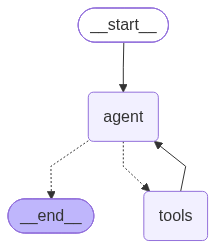

In [4]:
# ============================================
# Operations Agent – Your Models + Thread Memory
# ============================================

import os
from dotenv import load_dotenv
load_dotenv()

from typing import TypedDict, Annotated, Sequence
import operator
import json
import uuid

from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from litellm import completion

# -------------------------------------------------
# 1. Your Model Routing (from config)
# -------------------------------------------------
PRIMARY_MODEL = os.getenv("PRIMARY_MODEL", "gemini/gemini-3.5-flash")
FALLBACK_MODEL_1 = os.getenv("FALLBACK_MODEL_1", "groq/qwen/qwen3.8-27b")
FALLBACK_MODEL_2 = os.getenv("FALLBACK_MODEL_2", "groq/openai/gpt-oss-120b")

MODEL_FALLBACKS = [
    PRIMARY_MODEL,
    FALLBACK_MODEL_1,
    FALLBACK_MODEL_2,
]

def call_llm(messages: list, temperature: float = 0.2):
    """LiteLLM with your primary + fallback models"""
    last_error = None
    for model in MODEL_FALLBACKS:
        try:
            response = completion(
                model=model,
                messages=messages,
                temperature=temperature,
                max_tokens=2048,
            )
            print(f"✅ Used model: {model}")
            return response.choices[0].message.content
        except Exception as e:
            print(f"⚠️  {model} failed: {str(e)[:90]}")
            last_error = e
            continue
    raise Exception(f"All models failed. Last error: {last_error}")


# -------------------------------------------------
# 2. Tools
# -------------------------------------------------
@tool
def okf_retrieve(query: str) -> str:
    """
    Retrieve information from Operations Knowledge Base (SOPs).
    Use for: production reports, shift handover, work order compliance,
    metrics calculation, escalation, achievement %, missing evidence, etc.
    """
    try:
        return build_llm_context(query, top_k=4)
    except Exception as e:
        return f"Error retrieving from knowledge base: {str(e)}"


@tool
def general_knowledge(query: str) -> str:
    """
    Use only for general questions NOT related to plant SOPs or MES data.
    """
    messages = [
        {"role": "system", "content": "You are a helpful assistant. Answer concisely and accurately."},
        {"role": "user", "content": query}
    ]
    return call_llm(messages, temperature=0.3)


tools = [okf_retrieve, general_knowledge]
tools_by_name = {t.name: t for t in tools}


# -------------------------------------------------
# 3. State + Memory
# -------------------------------------------------
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]


memory = MemorySaver()


# -------------------------------------------------
# 4. Nodes
# -------------------------------------------------
SYSTEM_PROMPT = """You are the **Operations Agent (OKF)** for a manufacturing plant.

Rules:
- Always use the okf_retrieve tool for any question related to SOPs, production reporting, work orders, compliance, metrics, escalation, shift handover.
- Never invent limits, targets, owners, or data.
- Always cite Document ID + Section (e.g. SOP-OPS-001 Section 7).
- If information is missing → say "Unable to verify from available SOPs".
- For pure general knowledge questions only → use general_knowledge tool.

Be precise, professional, and concise.
"""

def agent_node(state: AgentState):
    messages = state["messages"]
    
    openai_messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    
    for msg in messages:
        if isinstance(msg, HumanMessage):
            openai_messages.append({"role": "user", "content": msg.content})
        elif isinstance(msg, AIMessage):
            if msg.content:
                openai_messages.append({"role": "assistant", "content": msg.content})
        elif isinstance(msg, ToolMessage):
            openai_messages.append({
                "role": "user",
                "content": f"Tool '{msg.name}' returned:\n{msg.content}"
            })

    tool_desc = "\n".join([f"- {t.name}: {t.description}" for t in tools])
    
    openai_messages.append({
        "role": "user",
        "content": f"""Decide if you need a tool.

Available tools:
{tool_desc}

If you need a tool, reply ONLY with this JSON (no other text):
{{
  "tool": "tool_name",
  "query": "search query here"
}}

If you already have enough information from previous tool results, give the final answer directly.
"""
    })

    response = call_llm(openai_messages, temperature=0.1)
    
    # Try to parse tool call
    try:
        clean = response.strip()
        if "```" in clean:
            clean = clean.split("```")[1]
            if clean.startswith("json"):
                clean = clean[4:]
        clean = clean.strip()
        
        parsed = json.loads(clean)
        if "tool" in parsed and "query" in parsed:
            return {
                "messages": [AIMessage(
                    content="",
                    additional_kwargs={
                        "tool_call": {
                            "name": parsed["tool"],
                            "args": {"query": parsed["query"]}
                        }
                    }
                )]
            }
    except:
        pass
    
    return {"messages": [AIMessage(content=response)]}


def tool_node(state: AgentState):
    last_message = state["messages"][-1]
    tool_call = last_message.additional_kwargs.get("tool_call")
    
    if not tool_call:
        return {"messages": [AIMessage(content="No tool requested.")]}
    
    tool_name = tool_call["name"]
    tool_args = tool_call["args"]
    
    print(f"🛠️  Tool: {tool_name} | {tool_args.get('query', '')[:70]}...")
    
    tool_fn = tools_by_name.get(tool_name)
    result = tool_fn.invoke(tool_args) if tool_fn else f"Tool {tool_name} not found"
    
    return {
        "messages": [ToolMessage(
            content=str(result),
            name=tool_name,
            tool_call_id=str(uuid.uuid4())
        )]
    }


def should_continue(state: AgentState):
    last = state["messages"][-1]
    if isinstance(last, AIMessage) and last.additional_kwargs.get("tool_call"):
        return "tools"
    return END


# -------------------------------------------------
# 5. Build Graph with Memory
# -------------------------------------------------
workflow = StateGraph(AgentState)

workflow.add_node("agent", agent_node)
workflow.add_node("tools", tool_node)

workflow.set_entry_point("agent")
workflow.add_conditional_edges("agent", should_continue, {"tools": "tools", END: END})
workflow.add_edge("tools", "agent")

app = workflow.compile(checkpointer=memory)
print("✅ Agent ready")
print(f"   Primary  : {PRIMARY_MODEL}")
print(f"   Fallback1: {FALLBACK_MODEL_1}")
print(f"   Fallback2: {FALLBACK_MODEL_2}")


# -------------------------------------------------
# 6. Chat Helper (with Thread Memory)
# -------------------------------------------------
def ask(question: str, thread_id: str = "default"):
    print(f"\n👤 User: {question}")
    print("-" * 60)
    
    config = {"configurable": {"thread_id": thread_id}}
    
    result = app.invoke(
        {"messages": [HumanMessage(content=question)]},
        config=config
    )
    
    final_answer = result["messages"][-1].content
    print(f"\n🤖 Operations Agent:\n{final_answer}")
    return final_answer
app

In [5]:
# Same conversation thread
ask("How do I calculate achievement percentage according to the SOP?", thread_id="user1")
ask("What if planned quantity is zero?", thread_id="user1")   # remembers previous context

# New conversation
ask("What is OEE?", thread_id="user2")


👤 User: How do I calculate achievement percentage according to the SOP?
------------------------------------------------------------


12:40:59 - LiteLLM:WARNING: vertex_and_google_ai_studio_gemini.py:1095 - DeprecationWarning: `temperature`, `top_p`, and `top_k` continue to function for Gemini 3+ (gemini-3.5-flash) but are planned for removal in a future release. Move sampling guidance into the `system` instructions instead.
12:41:19 - LiteLLM:WARNING: vertex_and_google_ai_studio_gemini.py:1095 - DeprecationWarning: `temperature`, `top_p`, and `top_k` continue to function for Gemini 3+ (gemini-3.5-flash) but are planned for removal in a future release. Move sampling guidance into the `system` instructions instead.


✅ Used model: gemini/gemini-3.5-flash
🛠️  Tool: okf_retrieve | calculate achievement percentage...


12:41:40 - LiteLLM:WARNING: vertex_and_google_ai_studio_gemini.py:1095 - DeprecationWarning: `temperature`, `top_p`, and `top_k` continue to function for Gemini 3+ (gemini-3.5-flash) but are planned for removal in a future release. Move sampling guidance into the `system` instructions instead.


✅ Used model: gemini/gemini-3.5-flash
🛠️  Tool: okf_retrieve | achievement percentage calculation production metrics SOP...


...

12:44:15 - LiteLLM:WARNING: vertex_and_google_ai_studio_gemini.py:1095 - DeprecationWarning: `temperature`, `top_p`, and `top_k` continue to function for Gemini 3+ (gemini-3.5-flash) but are planned for removal in a future release. Move sampling guidance into the `system` instructions instead.


✅ Used model: gemini/gemini-3.5-flash
🛠️  Tool: okf_retrieve | OEE Overall Equipment Effectiveness...


12:44:29 - LiteLLM:WARNING: vertex_and_google_ai_studio_gemini.py:1095 - DeprecationWarning: `temperature`, `top_p`, and `top_k` continue to function for Gemini 3+ (gemini-3.5-flash) but are planned for removal in a future release. Move sampling guidance into the `system` instructions instead.


✅ Used model: gemini/gemini-3.5-flash
🛠️  Tool: okf_retrieve | OEE...
✅ Used model: gemini/gemini-3.5-flash

🤖 Operations Agent:
Unable to verify from available SOPs.


'Unable to verify from available SOPs.'